### Part 2: OpenTheChests
This notebook implements models and training with stable baselines3 for the 3 OTC environments.

Should take less than 10mn on any standard GPU.

#### Expected results :
##### v0 :
- Mean Episode Reward: 3.00 ± 0.00 
- Min/Max Reward: 3.00 / 3.00
- Mean Episode Length: 4 ± 1
##### v1 : 
- Mean Episode Reward: -5.62 ± 2.80
- Min/Max Reward: -15.00 / -3.00
- Mean Episode Length: 13 ± 1 
##### v2 : 
- Mean Episode Reward: -30.00 ± 0.00
- Min/Max Reward: -30.00 / -30.00
- Mean Episode Length: 525 ± 7

In [1]:
import warnings
import logging

# Suppress UserWarning and DeprecationWarning
warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', category=DeprecationWarning)

# Configure logger
logger = logging.getLogger()
logger.setLevel(logging.ERROR)

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import gymnasium as gym
from tqdm import tqdm
from stable_baselines3 import DQN
from sb3_contrib import RecurrentPPO


from register_envs import register_custom_envs
register_custom_envs()

import utils

from random import seed
# For reproductibility
seed(1)

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


#### OpenTheChests-v0 :

c:\Users\malopif\miniconda3\envs\rl\Lib\site-packages\gymnasium\envs\registration.py:512: DeprecationWarning: WARN: The environment OpenTheChests-v0 is out of date. You should consider upgrading to version `v2`.
  logger.deprecation(


Output()

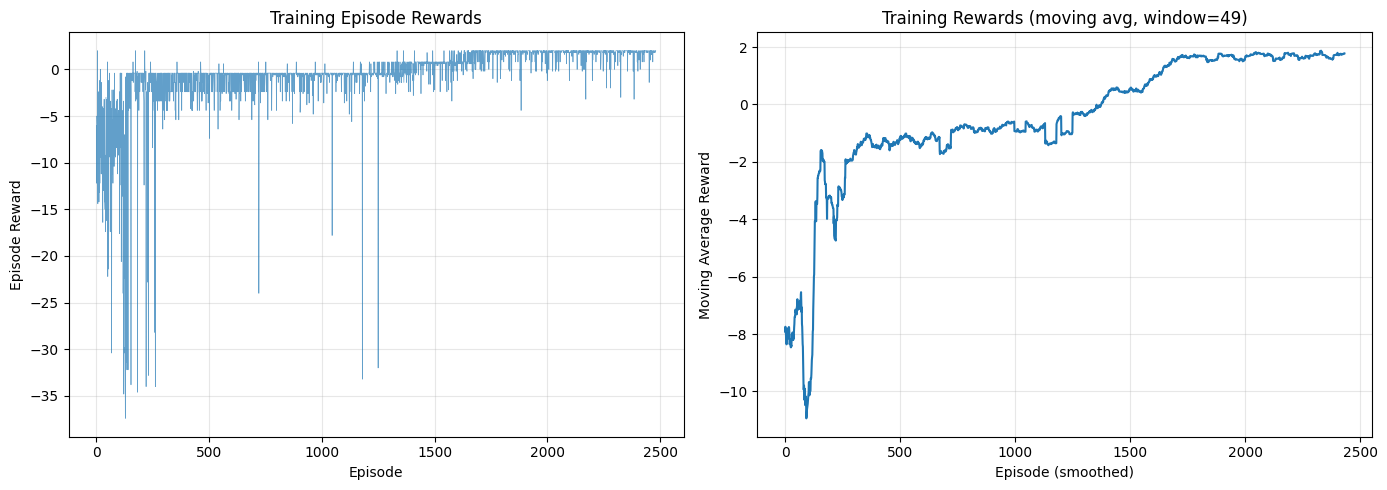

Total episodes trained: 2481
Mean reward: -0.52 ± 3.77
Best reward: 2.00
Best 20-episode avg: 1.95


In [ ]:
seed(1) #decent seed

# Initialize the OpenTheChestsGym environment
register_custom_envs()
env = gym.make("OpenTheChests-v0")
env = utils.ZeroRewardWrapper(env)
#Parameters
total_steps = 10000
lr = 1e-4


model = DQN("MultiInputPolicy", env, verbose=0, learning_rate=lr)

# custom callback : saves best versions, optional LR tracking (for debugging mainly)
callback = utils.RewardHistoryCallback(model=model, save_path="checkpoints/best_model_v0")

model.learn(total_steps, progress_bar=True, callback=callback)

callback.plot()


#### OpenTheChests-v1 :

c:\Users\malopif\miniconda3\envs\rl\Lib\site-packages\gymnasium\envs\registration.py:512: DeprecationWarning: WARN: The environment OpenTheChests-v1 is out of date. You should consider upgrading to version `v2`.
  logger.deprecation(


Output()

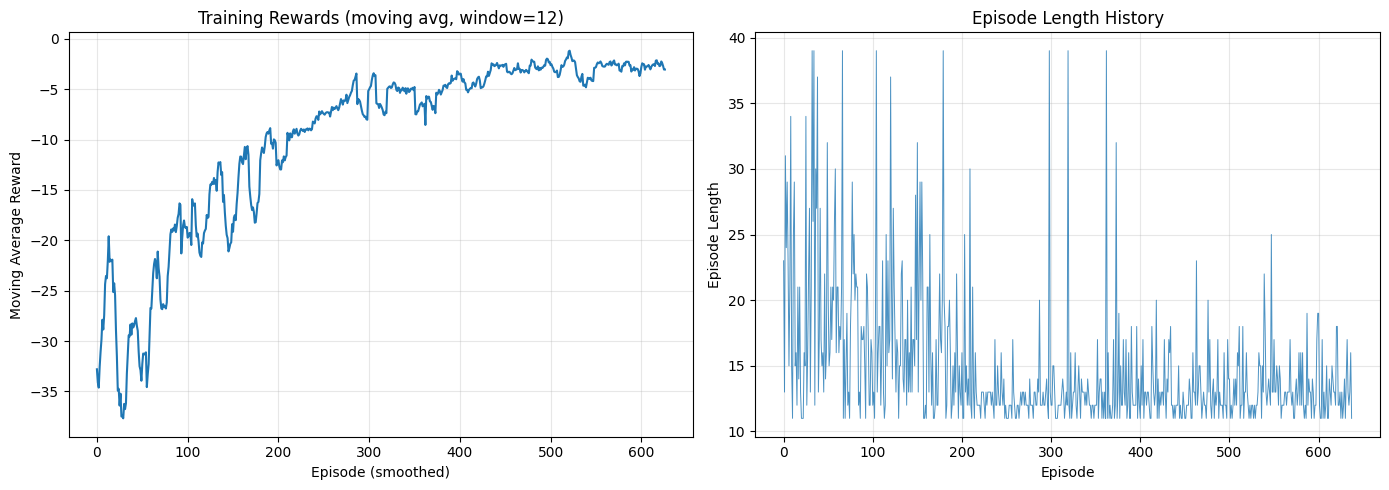

Total episodes trained: 638
Mean reward: -10.08 ± 11.32
Best reward: 0.20
Best 20-episode avg: -2.04
Mean episode length: 14.84 ± 5.13


In [3]:
# Initialize the OpenTheChestsGym environment
env = gym.make("OpenTheChests-v1", max_episode_steps=40) #speedup training
env = utils.FloatActionWrapper(env) #handle type conversion for sb3 compatibility
env = utils.ZeroRewardWrapper(env)

# Parameters
start_lr = 3e-3
min_lr = 1e-6
lstm_h_size = 128
lstm_n_layers = 1
total_steps = 10000


scheduler = utils.CosineAnnealingLR(start_lr, min_lr)

policy_kwargs = dict(
    lstm_hidden_size=lstm_h_size,
    n_lstm_layers=lstm_n_layers,
    enable_critic_lstm=False,
    share_features_extractor=True
)

model = RecurrentPPO(
    policy="MultiInputLstmPolicy",
    env=env,
    verbose=0,
    learning_rate=scheduler,
    policy_kwargs=policy_kwargs
)

# custom callback : saves best versions, optional LR tracking (for debugging mainly)
callback = utils.RewardHistoryCallback(model=model, save_path="checkpoints/best_model_v1")

model.learn(total_steps, progress_bar=True, callback=callback)

callback.plot()

#### OpenTheChests-v2 :

Output()

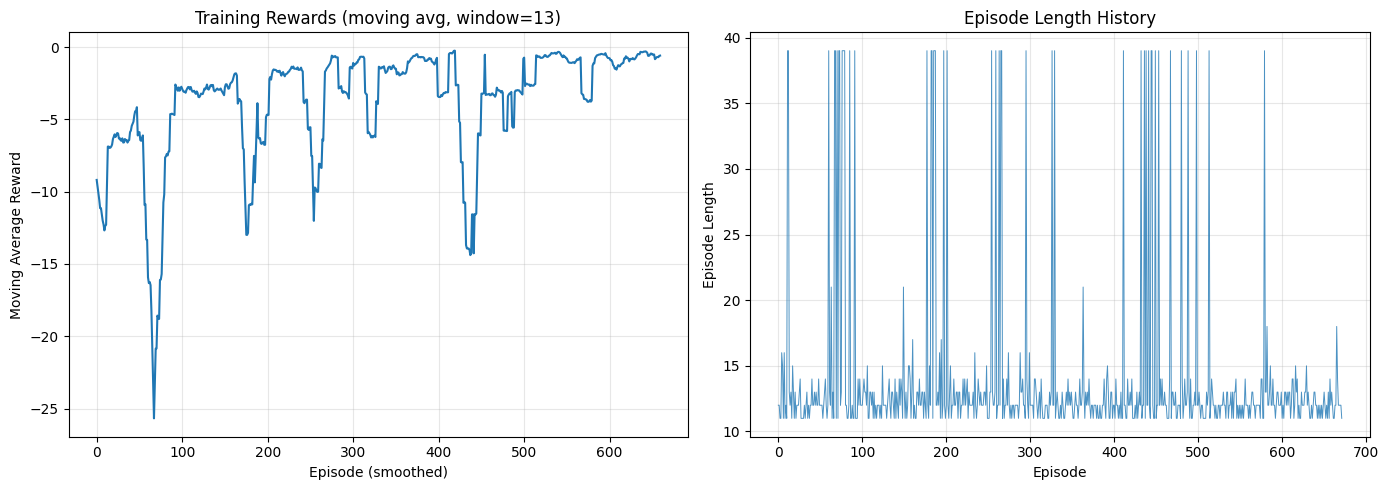

Total episodes trained: 672
Mean reward: -3.79 ± 8.06
Best reward: 0.20
Best 20-episode avg: -0.33
Mean episode length: 14.03 ± 6.80


In [5]:
env = gym.make("OpenTheChests-v2", max_episode_steps= 100) 
env = utils.FloatActionWrapper(env) #handle type conversion for sb3 compatibility
env = utils.ZeroRewardWrapper(env, -0.05)


# Parameters
start_lr = 3e-4
min_lr = 1e-5
lstm_h_size = 256
lstm_n_layers = 2
n_steps = 1024
total_steps = 10000
ent_coef = 0.05

scheduler = utils.CosineAnnealingLR(start_lr, min_lr)

policy_kwargs = dict(
    lstm_hidden_size=lstm_h_size,
    n_lstm_layers=lstm_n_layers,
    enable_critic_lstm=False,
    share_features_extractor=True
)
"""
model = RecurrentPPO(
    policy="MultiInputLstmPolicy",
    env=env,
    verbose=0,
    learning_rate=scheduler,
    policy_kwargs=policy_kwargs,
    ent_coef= ent_coef,
    n_steps=n_steps
)"""

# custom callback : saves best versions, optional LR tracking (for debugging mainly)
callback = utils.RewardHistoryCallback(model=model, save_path="checkpoints/best_model_v2")

model.learn(total_steps, progress_bar=True, callback=callback)

callback.plot()